# Multi-scale Analysis of Glacier Surface Roughness

## Imports

In [1]:
import pandas as pd
import numpy as np
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from typing import Optional, Tuple

# Footprint tools are optional in this HEFEX-focused notebook version
try:
    import src.calc_footprint_FFP_climatology as footprint
    from src.flux_footprints import subset_or_resample, filter_ffp, footprint_area
    FOOTPRINT_AVAILABLE = True
except Exception as exc:
    FOOTPRINT_AVAILABLE = False
    print(f"Footprint tools unavailable: {exc}")

    def subset_or_resample(df, resample_minutes=None, time_window=None):
        if time_window is not None:
            start_ts, end_ts = time_window
            df = df.loc[start_ts:end_ts]
        if resample_minutes is not None:
            df = df.resample(f"{resample_minutes}min").mean(numeric_only=True)
        return df

    def filter_ffp(df, **kwargs):
        return df

    def footprint_area(x, y):
        return np.nan

## Configuration (filters, subsets, averaging)
All preprocessing parameters live here and are applied once to the full dataset after import so every downstream plot uses the same filtered/averaged data. Adjust as needed and re-run the notebook from the top. Only for time series plots an individual averaging time can be set for better visualization.

In [2]:
# Constants
kappa = 0.41 # von Karman constant

# Heights of measurements (z) in meters
z1 = 1.1 # m
z2 = 2.1 # m
z3 = 3.1 # m

# -------------------------------------------------------------------------------------------
# SET GLOBAL PREPROCESSING PARAMETERS HERE

# Time window: set a tuple (start_ts, end_ts) or None
global_time_window = None  # e.g., (pd.Timestamp("2025-02-01"), pd.Timestamp("2025-02-15"))

# Averaging: set minutes (int) or None to skip averaging
global_resample_minutes = None  # e.g., 30 for 30-min means across the notebook

# Stability cutoff (applied to all heights -- Fitzpatrick uses -0.1 < z/L < 0.2)
stability_range = (-0.1, 0.2)

# Wind-regime ranges used across plots
katabatic = (80, 150)
crosswind = (170, 230)
anabatic = (240, 300)

# Global wind/dynamics filters (applied once right after import)
preprocess_wind_dir_range: Optional[Tuple[float, float]] = None         # katabatic, crosswind, or anabatic
preprocess_wind_speed_range: Optional[Tuple[float, float]] = (1, 50)    # (min, max)
preprocess_uw_jet_filter: Optional[bool] = True                         # if True, filter out data points where u'w' > 0
preprocess_uT_jet_filter: Optional[bool] = True                         # if True, filter out data points where u'T' < 0
preprocess_jet_dir_range: Optional[Tuple[float, float]] = katabatic     # wind direction range for jet filters (should be katabatic)
preprocess_ustar_range: Optional[Tuple[float, float]] = None            # (min, max)
preprocess_ustar_min: Optional[float] = 0.1                             # use if only a lower limit is needed

In [3]:
# Load HEFEX III 1-minute NetCDF datasets and build analysis table
hefex_root = Path("data/HEFEXIII")
standard_path = hefex_root / "fluxes_20Hz_1min.nc"
smartflux_path = hefex_root / "fluxes_20Hz_smart_1min.nc"

standard_ds = xr.open_dataset(standard_path)
smartflux_ds = xr.open_dataset(smartflux_path)

# Ensure z0 exists in both datasets (fallback compute if missing)
def add_neutral_z0(ds, wind_var="meanU", ustar_var="ustar", height_coord="heights", kappa=0.41):
    if "z0" in ds:
        return ds
    if wind_var not in ds or ustar_var not in ds or height_coord not in ds.coords:
        return ds
    z = ds[height_coord]
    u = ds[wind_var]
    ustar = ds[ustar_var]
    valid = (ustar > 0) & np.isfinite(u) & np.isfinite(ustar)
    z0 = xr.where(valid, z * np.exp(-(kappa * u) / ustar), np.nan)
    z0.name = "z0"
    z0.attrs.update({
        "long_name": "Aerodynamic roughness length (neutral, no stability correction)",
        "units": "m",
    })
    return ds.assign(z0=z0)

standard_ds = add_neutral_z0(standard_ds)
smartflux_ds = add_neutral_z0(smartflux_ds)

# Merge variables by preferring standard and filling gaps with smartflux
def merged_var(var_name):
    if var_name in standard_ds and var_name in smartflux_ds:
        return standard_ds[var_name].combine_first(smartflux_ds[var_name])
    if var_name in standard_ds:
        return standard_ds[var_name]
    if var_name in smartflux_ds:
        return smartflux_ds[var_name]
    return None

candidate_heights = sorted(set(np.asarray(standard_ds.heights.values, dtype=float)).union(set(np.asarray(smartflux_ds.heights.values, dtype=float))))
target_heights = {"1m": 1.0, "2m": 2.0, "3m": 3.0}
selected = {}
used = set()
for label, target in target_heights.items():
    choices = sorted(candidate_heights, key=lambda h: abs(h - target))
    pick = next((h for h in choices if h not in used), choices[0])
    selected[label] = pick
    used.add(pick)

print("Using HEFEX heights:", selected)

time_ref = merged_var("meanU")
if time_ref is None:
    raise ValueError("meanU missing in both HEFEX datasets.")
df_clean = pd.DataFrame(index=pd.DatetimeIndex(time_ref.time.values, name="datetime"))

var_map = {
    "wind_speed": "meanU",
    "wind_dir": "sdir",
    "u*": "ustar",
    "TKE": "tke",
    "cov_uw": "uw",
    "cov_uT": "uT",
    "var_v": "vv",
    "z0": "z0",
}

for lvl, h in selected.items():
    for out_prefix, src_var in var_map.items():
        da = merged_var(src_var)
        col = f"{out_prefix}_{lvl}"
        if da is None or "heights" not in da.dims:
            df_clean[col] = np.nan
            continue
        series = da.sel(heights=h, method="nearest").to_series()
        series.index = pd.to_datetime(series.index)
        df_clean[col] = series.reindex(df_clean.index)

# Add placeholder columns expected by downstream logic
for lvl in ["1m", "2m", "3m"]:
    df_clean[f"L_{lvl}"] = np.nan
    df_clean[f"(z-d)/L_{lvl}"] = np.nan
    df_clean[f"T*_{lvl}"] = np.nan

# Optional global subset / averaging
df_clean = subset_or_resample(
    df_clean,
    resample_minutes=global_resample_minutes,
    time_window=global_time_window,
)
if df_clean.empty:
    raise ValueError("No data left after global time selection/resampling; adjust settings.")
print(f"Rows after import/time selection: {len(df_clean)}")

# Convert to numeric robustly
for col in df_clean.columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Helper masks for directional ranges with wrap-around
def direction_mask(series: pd.Series, rng: Optional[Tuple[float, float]]) -> pd.Series:
    if rng is None:
        return pd.Series(True, index=series.index)
    lo, hi = rng
    vals = pd.to_numeric(series, errors='coerce') % 360
    if lo <= hi:
        return vals.between(lo, hi, inclusive='both')
    return (vals >= lo) | (vals <= hi)

levels = ["1m", "2m", "3m"]
level_cols = {lvl: [c for c in df_clean.columns if c.endswith(f"_{lvl}")] for lvl in levels}

# Apply wind and flux filters per level
for lvl in levels:
    lvl_mask = pd.Series(True, index=df_clean.index)

    lvl_mask &= direction_mask(df_clean.get(f"wind_dir_{lvl}", pd.Series(index=df_clean.index)), preprocess_wind_dir_range)

    if preprocess_wind_speed_range is not None:
        ws_lo, ws_hi = preprocess_wind_speed_range
        ws = pd.to_numeric(df_clean.get(f"wind_speed_{lvl}", pd.Series(index=df_clean.index)), errors="coerce")
        lvl_mask &= ws.between(ws_lo, ws_hi, inclusive="both")

    if preprocess_ustar_range is not None:
        us_lo, us_hi = preprocess_ustar_range
        us = pd.to_numeric(df_clean.get(f"u*_{lvl}", pd.Series(index=df_clean.index)), errors="coerce")
        lvl_mask &= us.between(us_lo, us_hi, inclusive="both")
    if preprocess_ustar_min is not None:
        us = pd.to_numeric(df_clean.get(f"u*_{lvl}", pd.Series(index=df_clean.index)), errors="coerce")
        lvl_mask &= us >= preprocess_ustar_min

    jet_mask = direction_mask(df_clean.get(f"wind_dir_{lvl}", pd.Series(index=df_clean.index)), preprocess_jet_dir_range)
    if preprocess_uw_jet_filter:
        lvl_mask &= (~jet_mask) | (df_clean.get(f"cov_uw_{lvl}", pd.Series(index=df_clean.index)) <= 0)
    if preprocess_uT_jet_filter:
        lvl_mask &= (~jet_mask) | (df_clean.get(f"cov_uT_{lvl}", pd.Series(index=df_clean.index)) >= 0)

    df_clean.loc[~lvl_mask, level_cols[lvl]] = np.nan

rows_with_any = df_clean[level_cols["1m"] + level_cols["2m"] + level_cols["3m"]].dropna(how="all").shape[0]
print(f"Rows with any valid data after preprocessing filters: {rows_with_any}")

# Wind-direction counts per regime (per level)
def count_dir_range(vals: pd.Series, rng: Tuple[float, float]) -> int:
    vals = vals.dropna()
    if vals.empty:
        return 0
    lo, hi = rng
    if lo <= hi:
        return int(vals.between(lo, hi, inclusive='both').sum())
    return int(((vals >= lo) | (vals <= hi)).sum())

wd_levels = {lvl: pd.to_numeric(df_clean.get(f"wind_dir_{lvl}", pd.Series(index=df_clean.index)), errors="coerce") % 360 for lvl in levels}
regimes = {"katabatic": katabatic, "crosswind": crosswind, "anabatic": anabatic}
dir_counts = {name: {lvl: count_dir_range(wd_levels[lvl], rng) for lvl in levels} for name, rng in regimes.items()}
dir_table = pd.DataFrame.from_dict(dir_counts, orient="index")[levels]
dir_table.loc["total"] = dir_table.sum(axis=0)
dir_table.index.name = "wind_dir_range"
print("\nWind direction counts (rows passing filters):")
print(dir_table.to_string())

# Use preprocessed dataframe for all plots
df_plot = df_clean

Using HEFEX heights: {'1m': np.float64(1.0), '2m': np.float64(3.0), '3m': np.float64(5.0)}
Rows after import/time selection: 36681
Rows with any valid data after preprocessing filters: 27586

Wind direction counts (rows passing filters):
                   1m     2m     3m
wind_dir_range                     
katabatic          11     32     33
crosswind       15285  18502  20399
anabatic          319    401    426
total           15615  18935  20858


## Functions

### Plots

In [4]:
def plot_wind_rose(ax, directions, title, n_bins=16, color="blue"):
    """
    Plot an individual wind rose
    
    Parameters
    ----------
    ax : matplotlib.axes._subplots.PolarAxesSubplot
        The axes on which to plot the wind rose.
    directions : array-like
        Wind directions in degrees.
    title : str
        Title of the plot.
    n_bins : int, optional
        Number of bins for the wind directions (default is 16).
    color : str, optional
        Color of the bars (default is "blue").
    """
    dirs = pd.to_numeric(directions, errors='coerce').dropna() % 360
    bins = np.linspace(0, 360, n_bins + 1)
    counts, _ = np.histogram(dirs, bins=bins)
    widths = np.deg2rad(np.diff(bins))
    angles = np.deg2rad(bins[:-1]) + widths / 2
    freq = counts / counts.sum() * 100
    ax.bar(angles, freq, width=widths, bottom=0, align='center', color=color, edgecolor='k', linewidth=0.3, alpha=0.7)
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1)
    ax.set_title(title, pad=15)
    ax.set_xticks(np.deg2rad(np.arange(0, 360, 45)))
    ax.set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
    ax.set_yticks([5, 10, 15, 20, 25])
    ax.set_yticklabels([f"{int(t)}%" for t in ax.get_yticks()])
    ax.grid(True, alpha=0.3)

def compute_freq(directions, bins):
    """
    Compute the frequency of wind directions within specified bins.

    Parameters
    ----------
    directions : array-like
        Wind directions in degrees.
    bins : array-like
        Bin edges for the histogram.

    Returns
    -------
    array
        Frequency of wind directions in each bin as a percentage.
    """
    dirs = pd.to_numeric(directions, errors='coerce').dropna() % 360
    counts, _ = np.histogram(dirs, bins=bins)
    return counts / counts.sum() * 100


def custom_date_formatter(x, _):
    """
    Custom formatter to remove leading zeros from month
    """
    date = mdates.num2date(x)
    return f"{date.day}.{date.month}."


def resample_for_plot(df: pd.DataFrame, minutes: Optional[int]) -> pd.DataFrame:
    """Optional plot-only resampling helper for cleaner time-series visuals."""
    if minutes is None:
        return df
    return df.resample(f"{minutes}min").mean(numeric_only=True)

## Basic plots

Skipping stability time series: no valid (z-d)/L data in HEFEX III files.


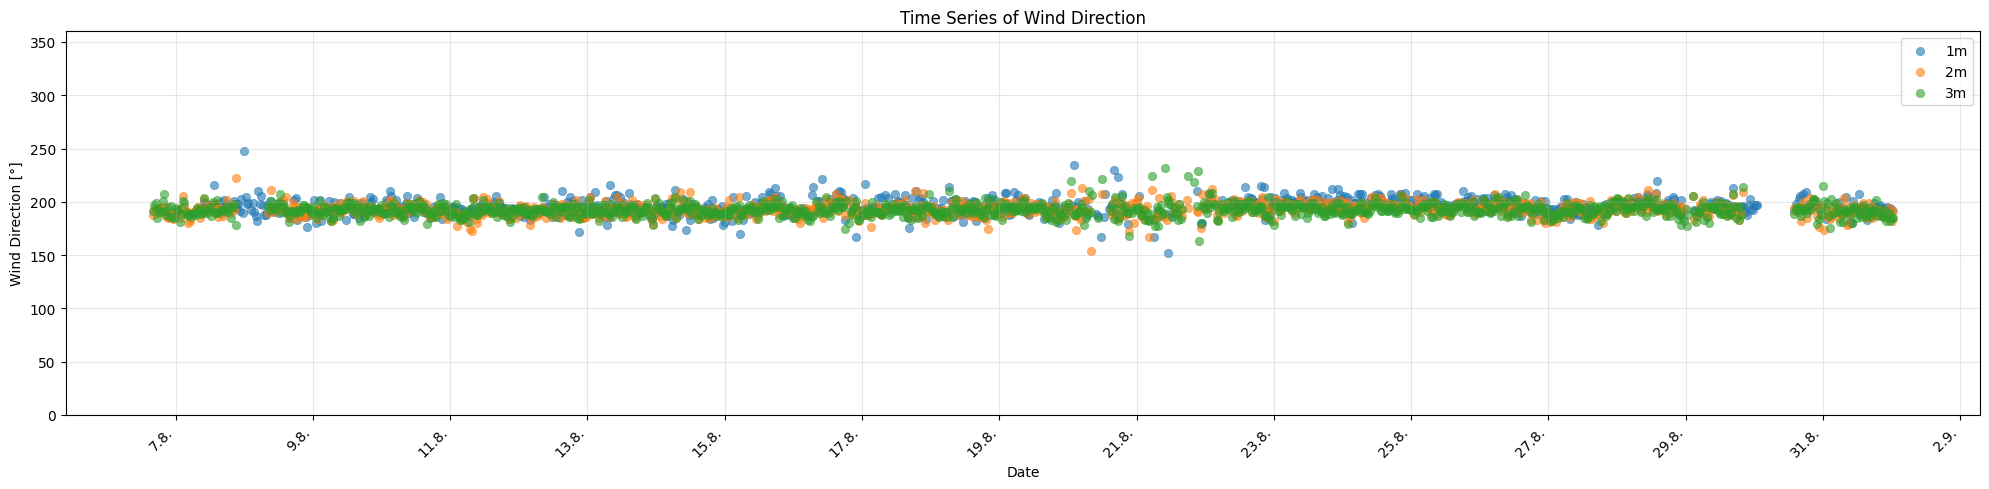

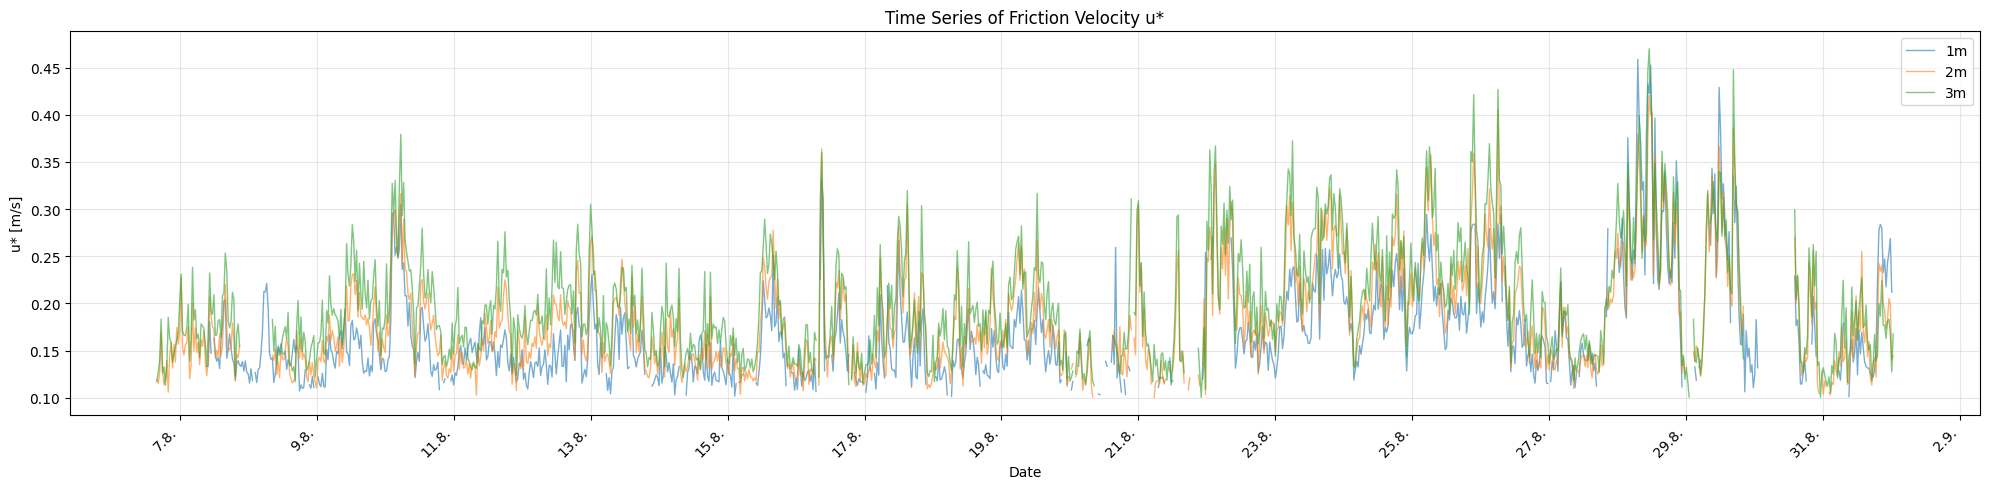

In [19]:
# Time series (kept here, histograms are in the next cell)
plot_resample_minutes = 30  # e.g., 10 to smooth

# 1. Time series of stability parameter (z-d)/L (optional if present)
cols_L = ['(z-d)/L_1m', '(z-d)/L_2m', '(z-d)/L_3m']
df_ts_L = resample_for_plot(df_plot[cols_L], plot_resample_minutes)
if df_ts_L.notna().sum().sum() > 0:
    fig_ts1, ax_ts1 = plt.subplots(figsize=(20, 5))
    ax_ts1.plot(df_ts_L.index, df_ts_L['(z-d)/L_1m'], label='1m', alpha=0.6, linewidth=1)
    ax_ts1.plot(df_ts_L.index, df_ts_L['(z-d)/L_2m'], label='2m', alpha=0.6, linewidth=1)
    ax_ts1.plot(df_ts_L.index, df_ts_L['(z-d)/L_3m'], label='3m', alpha=0.6, linewidth=1)
    ax_ts1.set_ylabel('(z-d)/L [-]')
    ax_ts1.set_xlabel('Date')
    ax_ts1.set_title('Time Series of Stability Parameter (z-d)/L')
    ax_ts1.legend()
    ax_ts1.grid(True, alpha=0.3)
    ax_ts1.axhline(y=0, color='k', linestyle='--', linewidth=0.8)
    ax_ts1.xaxis.set_major_formatter(FuncFormatter(custom_date_formatter))
    ax_ts1.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    fig_ts1.autofmt_xdate(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('Skipping stability time series: no valid (z-d)/L data in HEFEX III files.')

# 2. Time series of wind direction
cols_wd = ['wind_dir_1m', 'wind_dir_2m', 'wind_dir_3m']
df_ts_wd = resample_for_plot(df_plot[cols_wd], plot_resample_minutes)
fig_ts2, ax_ts2 = plt.subplots(figsize=(20, 5))
ax_ts2.scatter(df_ts_wd.index, df_ts_wd['wind_dir_1m'], label='1m', alpha=0.6, linewidth=0.5)
ax_ts2.scatter(df_ts_wd.index, df_ts_wd['wind_dir_2m'], label='2m', alpha=0.6, linewidth=0.5)
ax_ts2.scatter(df_ts_wd.index, df_ts_wd['wind_dir_3m'], label='3m', alpha=0.6, linewidth=0.5)
ax_ts2.set_ylabel('Wind Direction [°]')
ax_ts2.set_xlabel('Date')
ax_ts2.set_title('Time Series of Wind Direction')
ax_ts2.set_ylim(0, 360)
ax_ts2.legend()
ax_ts2.grid(True, alpha=0.3)
ax_ts2.xaxis.set_major_formatter(FuncFormatter(custom_date_formatter))
ax_ts2.xaxis.set_major_locator(mdates.DayLocator(interval=2))
fig_ts2.autofmt_xdate(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 3. Time series of friction velocity u*
cols_ustar = ['u*_1m', 'u*_2m', 'u*_3m']
df_ts_ustar = resample_for_plot(df_plot[cols_ustar], plot_resample_minutes)
fig_ts3, ax_ts3 = plt.subplots(figsize=(20, 5))
ax_ts3.plot(df_ts_ustar.index, df_ts_ustar['u*_1m'], label='1m', alpha=0.6, linewidth=1)
ax_ts3.plot(df_ts_ustar.index, df_ts_ustar['u*_2m'], label='2m', alpha=0.6, linewidth=1)
ax_ts3.plot(df_ts_ustar.index, df_ts_ustar['u*_3m'], label='3m', alpha=0.6, linewidth=1)
ax_ts3.set_ylabel('u* [m/s]')
ax_ts3.set_xlabel('Date')
ax_ts3.set_title('Time Series of Friction Velocity u*')
ax_ts3.legend()
ax_ts3.grid(True, alpha=0.3)
ax_ts3.xaxis.set_major_formatter(FuncFormatter(custom_date_formatter))
ax_ts3.xaxis.set_major_locator(mdates.DayLocator(interval=2))
fig_ts3.autofmt_xdate(rotation=45, ha='right')
plt.tight_layout()
plt.show()

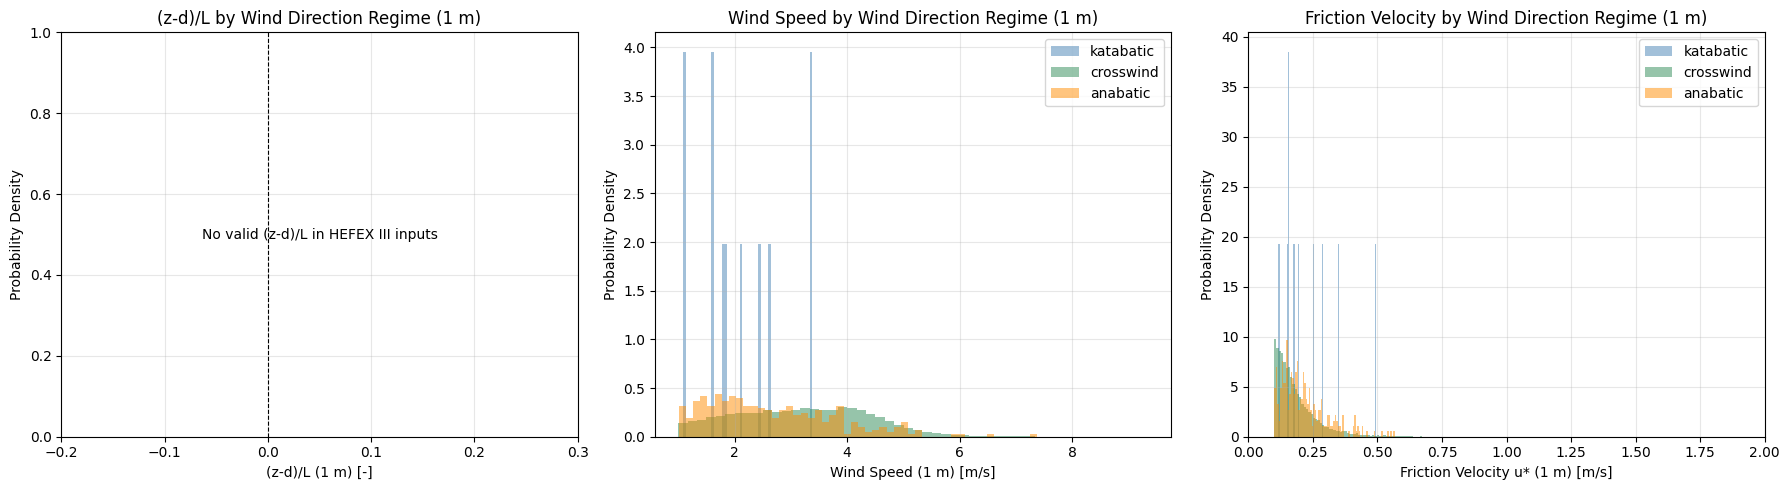

In [21]:
# Histograms and distributions

# Distributions at 1 m by wind-direction regime: (z-d)/L, wind speed, and friction velocity u*
ws_1m = pd.to_numeric(df_plot['wind_speed_1m'], errors='coerce')
ustar_1m = pd.to_numeric(df_plot['u*_1m'], errors='coerce')
wd_1m = pd.to_numeric(df_plot['wind_dir_1m'], errors='coerce')
zdl_1m = pd.to_numeric(df_plot['(z-d)/L_1m'], errors='coerce')

mask_kata = (wd_1m >= katabatic[0]) & (wd_1m <= katabatic[1])
mask_cross = (wd_1m >= crosswind[0]) & (wd_1m <= crosswind[1])
mask_ana = (wd_1m >= anabatic[0]) & (wd_1m <= anabatic[1])

fig, (ax_a, ax_b, ax_c) = plt.subplots(1, 3, figsize=(18, 5))

# (z-d)/L (optional if available)
zdl_has_data = (zdl_1m[mask_kata].dropna().size + zdl_1m[mask_cross].dropna().size + zdl_1m[mask_ana].dropna().size) > 0
if zdl_has_data:
    ax_a.hist(zdl_1m[mask_kata].dropna(), bins=50, label='katabatic', density=True, color='steelblue', alpha=0.5)
    ax_a.hist(zdl_1m[mask_cross].dropna(), bins=50, label='crosswind', density=True, color='seagreen', alpha=0.5)
    ax_a.hist(zdl_1m[mask_ana].dropna(), bins=50, label='anabatic', density=True, color='darkorange', alpha=0.5)
    ax_a.legend()
else:
    ax_a.text(0.5, 0.5, 'No valid (z-d)/L in HEFEX III inputs', ha='center', va='center', transform=ax_a.transAxes)
ax_a.set_xlabel('(z-d)/L (1 m) [-]')
ax_a.set_ylabel('Probability Density')
ax_a.set_title('(z-d)/L by Wind Direction Regime (1 m)')
ax_a.grid(True, alpha=0.3)
ax_a.axvline(x=0, color='k', linestyle='--', linewidth=0.8)
ax_a.set_xlim(-0.2, 0.3)

# Wind speed
ax_b.hist(ws_1m[mask_kata].dropna(), bins=50, label='katabatic', density=True, color='steelblue', alpha=0.5)
ax_b.hist(ws_1m[mask_cross].dropna(), bins=50, label='crosswind', density=True, color='seagreen', alpha=0.5)
ax_b.hist(ws_1m[mask_ana].dropna(), bins=50, label='anabatic', density=True, color='darkorange', alpha=0.5)
ax_b.set_xlabel('Wind Speed (1 m) [m/s]')
ax_b.set_ylabel('Probability Density')
ax_b.set_title('Wind Speed by Wind Direction Regime (1 m)')
ax_b.grid(True, alpha=0.3)
ax_b.legend()

# Friction velocity u*
ax_c.hist(ustar_1m[mask_kata].dropna(), bins=80, label='katabatic', density=True, color='steelblue', alpha=0.5)
ax_c.hist(ustar_1m[mask_cross].dropna(), bins=80, label='crosswind', density=True, color='seagreen', alpha=0.5)
ax_c.hist(ustar_1m[mask_ana].dropna(), bins=80, label='anabatic', density=True, color='darkorange', alpha=0.5)
ax_c.set_xlabel('Friction Velocity u* (1 m) [m/s]')
ax_c.set_ylabel('Probability Density')
ax_c.set_title('Friction Velocity by Wind Direction Regime (1 m)')
ax_c.grid(True, alpha=0.3)
ax_c.set_xlim(0, 2)
ax_c.legend()

plt.tight_layout()
plt.show()

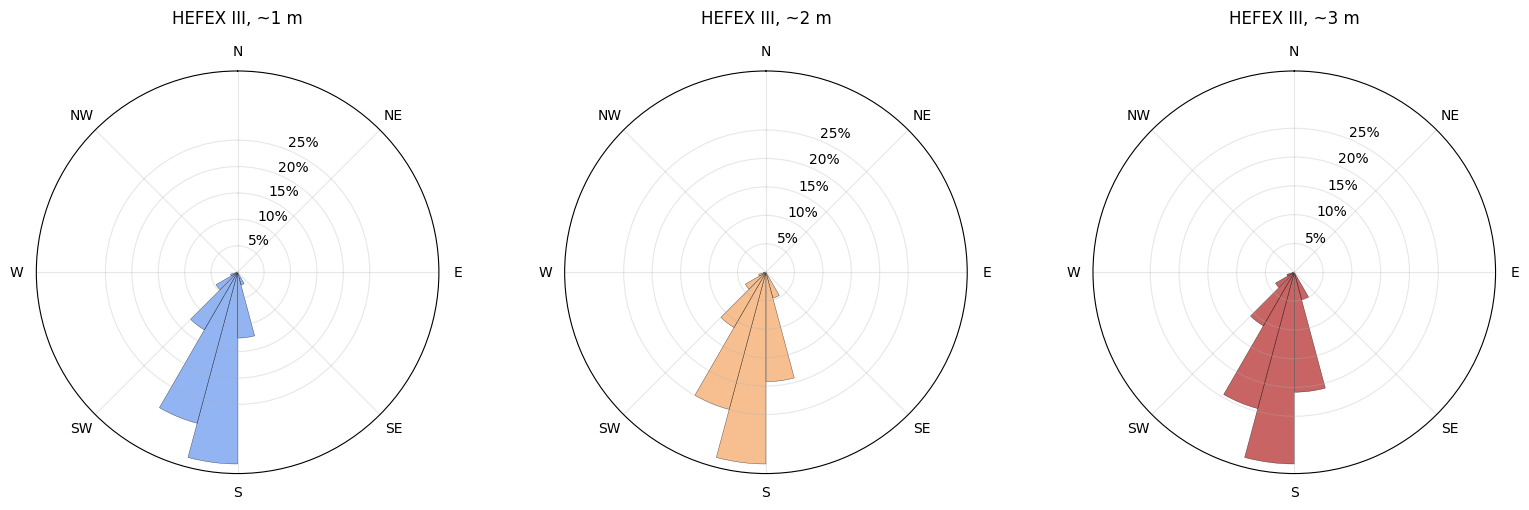

In [7]:
# Individual roses
n_bins = 24
bins = np.linspace(0, 360, n_bins + 1)
fig, axes = plt.subplots(1, 3, subplot_kw={'projection': 'polar'}, figsize=(16, 5))
plot_wind_rose(axes[0], df_plot['wind_dir_1m'], 'HEFEX III, ~1 m', n_bins=n_bins, color='cornflowerblue')
plot_wind_rose(axes[1], df_plot['wind_dir_2m'], 'HEFEX III, ~2 m', n_bins=n_bins, color='sandybrown')
plot_wind_rose(axes[2], df_plot['wind_dir_3m'], 'HEFEX III, ~3 m', n_bins=n_bins, color='firebrick')
plt.tight_layout()
plt.show()


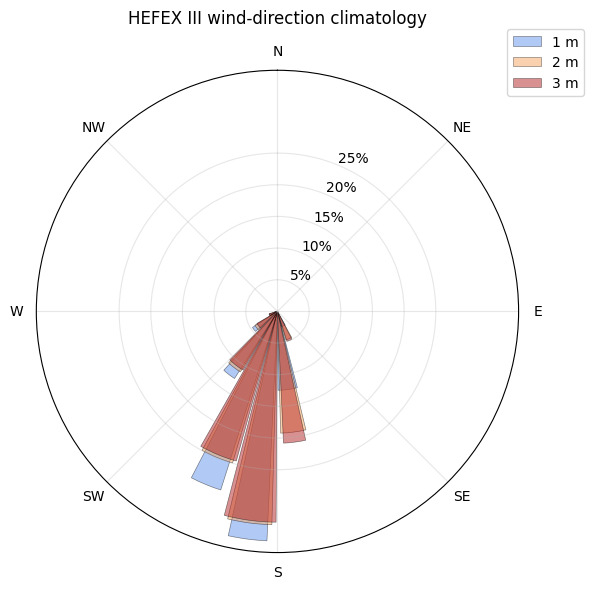

In [8]:
# Combined wind rose: overlapping bars per sector
widths = np.deg2rad(np.diff(bins))
angles = np.deg2rad(bins[:-1]) + widths / 2
freqs = {
    '1 m': compute_freq(df_plot['wind_dir_1m'], bins),
    '2 m': compute_freq(df_plot['wind_dir_2m'], bins),
    '3 m': compute_freq(df_plot['wind_dir_3m'], bins),
}
colors = {'1 m': 'cornflowerblue', '2 m': 'sandybrown', '3 m': 'firebrick'}
rank_widths = {0: 0.65, 1: 0.8, 2: 0.95}  # rank 0 = largest freq (narrowest bar)

levels = list(freqs.keys())
widths_by_level = {lvl: np.zeros_like(widths) for lvl in levels}
for i in range(len(widths)):
    sector_vals = {lvl: freqs[lvl][i] for lvl in levels}
    ordered = sorted(sector_vals.items(), key=lambda kv: kv[1], reverse=True)
    for rank, (lvl, _) in enumerate(ordered):
        widths_by_level[lvl][i] = widths[i] * rank_widths[rank]

fig_grouped = plt.figure(figsize=(6, 6))
ax_grouped = fig_grouped.add_subplot(111, projection='polar')
ax_grouped.patch.set_alpha(1)

for label, freq in freqs.items():
    ax_grouped.bar(
        angles,
        freq,
        width=widths_by_level[label],
        bottom=0,
        align='center',
        edgecolor='k',
        linewidth=0.45,
        alpha=0.5,
        color=colors[label],
        label=label,
    )
ax_grouped.set_theta_zero_location('N')
ax_grouped.set_theta_direction(-1)
ax_grouped.set_xticks(np.deg2rad(np.arange(0, 360, 45)))
ax_grouped.set_xticklabels(['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'])
ax_grouped.set_yticks([5, 10, 15, 20, 25])
ax_grouped.set_yticklabels([f"{int(t)}%" for t in ax_grouped.get_yticks()])
ax_grouped.set_title('HEFEX III wind-direction climatology', pad=15)
ax_grouped.grid(True, alpha=0.3)
ax_grouped.legend(loc='upper right', bbox_to_anchor=(1.15, 1.1))
plt.tight_layout()
plt.show()

## Aerodynamic roughness length

Compute aerodynamic roughness length from the standard MOST log wind profile (for neutral conditions), $u_z = \frac{u_*}{\kappa} \ln \left(\frac{z}{z_0} \right) \ \Longrightarrow \ z_0 = z \exp\left( - \frac{u_z \kappa}{u_*} \right)$ with the wind speed $u_z$ at height $z$, friction velocity $u_*$, the von Kármán constant $\kappa = 0.41$, and aerodynamic roughness length $z_0$.

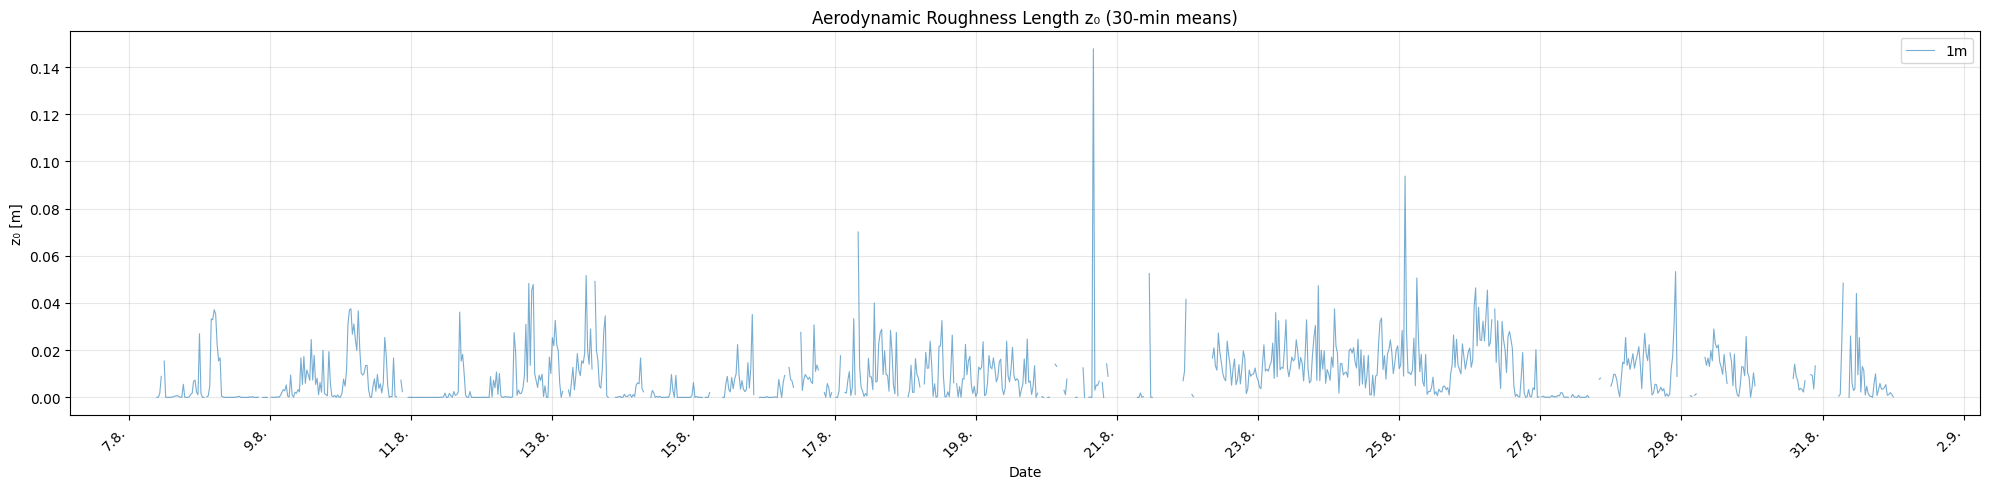

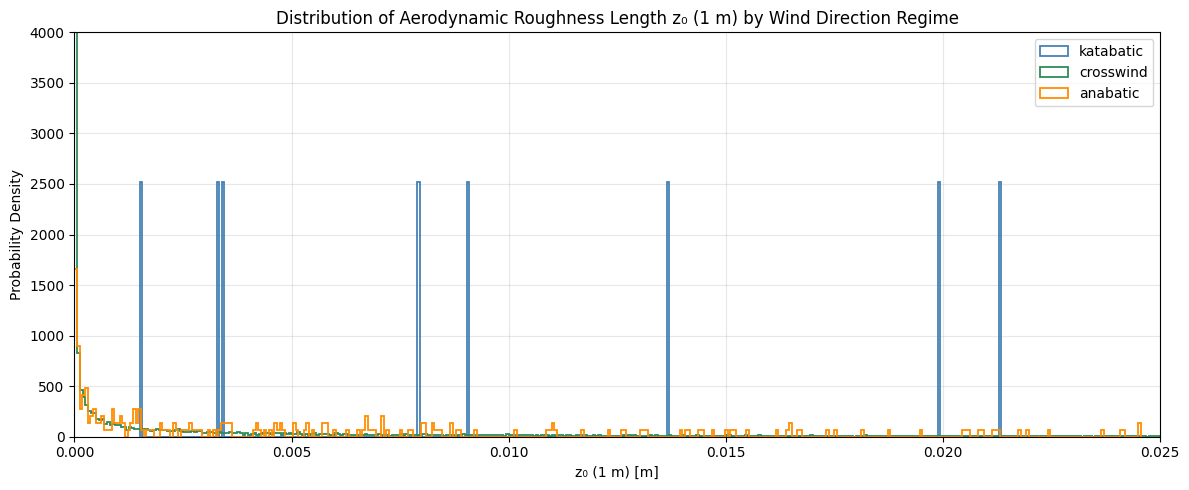

In [9]:
# Optional: set a plot-only averaging window (minutes) for this time series
plot_resample_minutes = 30  # e.g., 10 to smooth

# Histogram cutoff for z0 (set None to disable, otherwise values above are excluded from histogram)
hist_z0_max = 0.025

# 1. Time series of roughness length z0 (30-min means)
cols_z0 = ['z0_1m', 'z0_2m', 'z0_3m']
df_ts_z0 = resample_for_plot(df_clean[cols_z0], plot_resample_minutes)
fig1, ax1 = plt.subplots(figsize=(20, 5))
ax1.plot(df_ts_z0.index, df_ts_z0['z0_1m'], label='1m', alpha=0.6, linewidth=0.8)
#.plot(df_ts_z0.index, df_ts_z0['z0_2m'], label='2m', alpha=0.6, linewidth=0.8)
#ax1.plot(df_ts_z0.index, df_ts_z0['z0_3m'], label='3m', alpha=0.6, linewidth=0.8)
ax1.set_ylabel('z₀ [m]')
ax1.set_xlabel('Date')
ax1.set_title('Aerodynamic Roughness Length z₀ (30-min means)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.xaxis.set_major_formatter(FuncFormatter(custom_date_formatter))
ax1.xaxis.set_major_locator(mdates.DayLocator(interval=2))
fig1.autofmt_xdate(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Distribution of roughness length z0 by wind-direction regime (1 m only)
z0_1m = pd.to_numeric(df_clean['z0_1m'], errors='coerce')
if hist_z0_max is not None:
    z0_1m = z0_1m.where(z0_1m <= hist_z0_max)

wd_1m = pd.to_numeric(df_clean['wind_dir_1m'], errors='coerce') % 360
mask_kata = (wd_1m >= katabatic[0]) & (wd_1m <= katabatic[1])
mask_cross = (wd_1m >= crosswind[0]) & (wd_1m <= crosswind[1])
mask_ana = (wd_1m >= anabatic[0]) & (wd_1m <= anabatic[1])

fig2, ax2 = plt.subplots(figsize=(12, 5))
ax2.hist(z0_1m[mask_kata].dropna(), bins=400, histtype='step', linewidth=1.3, label='katabatic', density=True, color='steelblue')
ax2.hist(z0_1m[mask_cross].dropna(), bins=400, histtype='step', linewidth=1.3, label='crosswind', density=True, color='seagreen')
ax2.hist(z0_1m[mask_ana].dropna(), bins=400, histtype='step', linewidth=1.3, label='anabatic', density=True, color='darkorange')
ax2.set_xlabel('z₀ (1 m) [m]')
ax2.set_ylabel('Probability Density')
ax2.set_title('Distribution of Aerodynamic Roughness Length z₀ (1 m) by Wind Direction Regime')
ax2.set_xlim(0, hist_z0_max if hist_z0_max is not None else 0.005)
ax2.set_ylim(0, 4000)
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Diurnal pattern of z0 (all points vs. time of day)
#df_hour = df_clean[cols_z0].copy()
#df_hour['tod_hours'] = df_hour.index.hour + df_hour.index.minute / 60.0
#fig3, ax3 = plt.subplots(figsize=(10, 5))
#ax3.scatter(df_hour['tod_hours'], df_hour['z0_1m'], s=8, alpha=0.35, label='1m')
#ax3.scatter(df_hour['tod_hours'], df_hour['z0_2m'], s=8, alpha=0.35, label='2m')
#ax3.scatter(df_hour['tod_hours'], df_hour['z0_3m'], s=8, alpha=0.35, label='3m')
#ax3.set_xlabel('Hour of day')
#ax3.set_ylabel('z₀ [m]')
#ax3.set_title('Diurnal pattern of z₀ (all points)')
#ax3.set_xlim(0, 24)
#ax3.set_xticks(range(0, 25, 2))
#ax3.grid(True, alpha=0.3)
#ax3.legend()
#plt.tight_layout()
#plt.show()

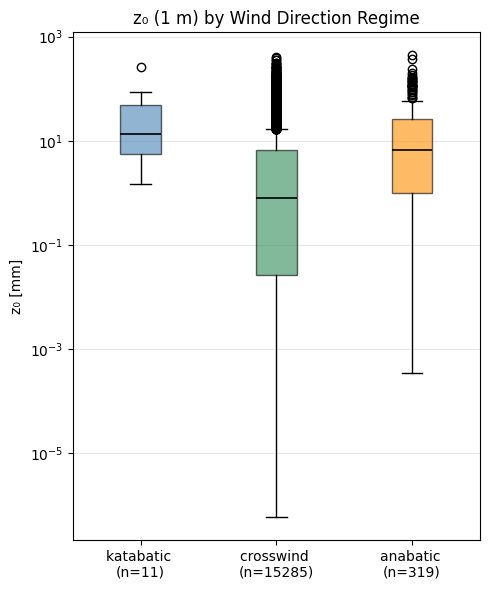

In [10]:
# Box plot of aerodynamic roughness length (neutral) at 1 m, grouped by wind-direction regime (in millimeters)
wd_1m = pd.to_numeric(df_clean['wind_dir_1m'], errors='coerce') % 360
z0_1m_mm = pd.to_numeric(df_clean['z0_1m'], errors='coerce') * 1000

mask_kata = (wd_1m >= katabatic[0]) & (wd_1m <= katabatic[1])
mask_cross = (wd_1m >= crosswind[0]) & (wd_1m <= crosswind[1])
mask_ana = (wd_1m >= anabatic[0]) & (wd_1m <= anabatic[1])

data_mm = [
    z0_1m_mm[mask_kata].dropna(),
    z0_1m_mm[mask_cross].dropna(),
    z0_1m_mm[mask_ana].dropna(),
 ]
labels = [
    f'katabatic \n(n={len(data_mm[0])})',
    f'crosswind \n(n={len(data_mm[1])})',
    f'anabatic \n(n={len(data_mm[2])})',
 ]
colors = ['steelblue', 'seagreen', 'darkorange']

fig, ax = plt.subplots(figsize=(5, 6))
bp0 = ax.boxplot(
    data_mm,
    tick_labels=labels,
    vert=True,
    patch_artist=True,
    showfliers=True,
    medianprops={'color': 'black', 'linewidth': 1.2},
 )
for patch, color in zip(bp0['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_title('z₀ (1 m) by Wind Direction Regime')
ax.set_ylabel('z₀ [mm]')
ax.grid(True, axis='y', alpha=0.3)

#all_data_concat = pd.concat(data_mm)
#upper_lim_mm = all_data_concat.quantile(0.99) if not all_data_concat.empty else None
#if pd.notna(upper_lim_mm):
#    ax.set_ylim(0, upper_lim_mm * 1.2)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

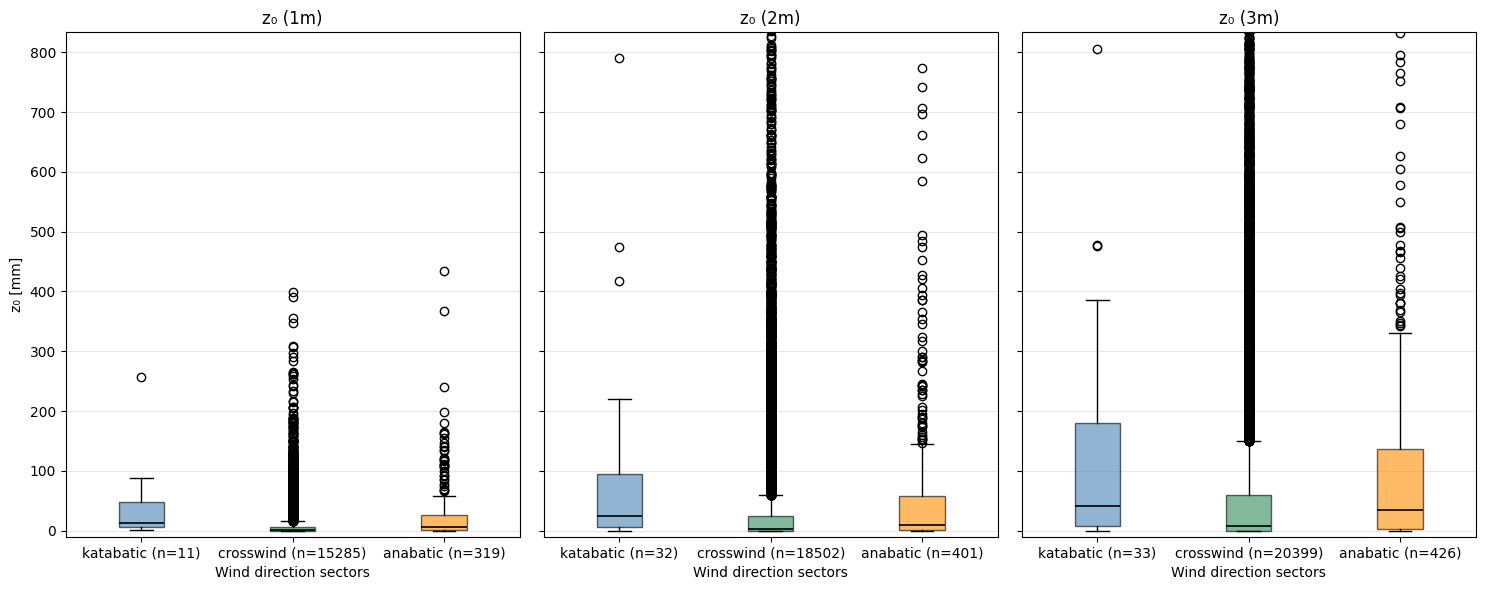

In [11]:
# Box plots: z₀ by predefined wind-direction regimes for 1 m, 2 m, and 3 m
sectors = [
    ("katabatic", katabatic),
    ("crosswind", crosswind),
    ("anabatic", anabatic),
 ]
sector_colors = ['steelblue', 'seagreen', 'darkorange']
heights = ['1m', '2m', '3m']

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
all_data = []

for ax, h in zip(axes, heights):
    wd = pd.to_numeric(df_clean[f'wind_dir_{h}'], errors='coerce')
    z0_mm = pd.to_numeric(df_clean[f'z0_{h}'], errors='coerce') * 1000

    labels = []
    data_mm = []
    for (name, (lo, hi)), color in zip(sectors, sector_colors):
        mask = direction_mask(wd, (lo, hi))
        subset = z0_mm[mask].dropna()
        data_mm.append(subset)
        labels.append(f"{name} (n={len(subset)})")

    bp = ax.boxplot(
        data_mm,
        tick_labels=labels,
        vert=True,
        patch_artist=True,
        showfliers=True,
        medianprops={'color': 'black', 'linewidth': 1.2},
    )
    for patch, color in zip(bp['boxes'], sector_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    ax.set_title(f'z₀ ({h})')
    ax.set_xlabel('Wind direction sectors')
    ax.grid(True, axis='y', alpha=0.3)
    if h == '1m':
        ax.set_ylabel('z₀ [mm]')

    all_data.extend(data_mm)

upper_lim_mm = pd.concat(all_data).quantile(0.99)
if pd.notna(upper_lim_mm):
    axes[0].set_ylim(-10, upper_lim_mm * 1.2)

plt.tight_layout()
plt.show()

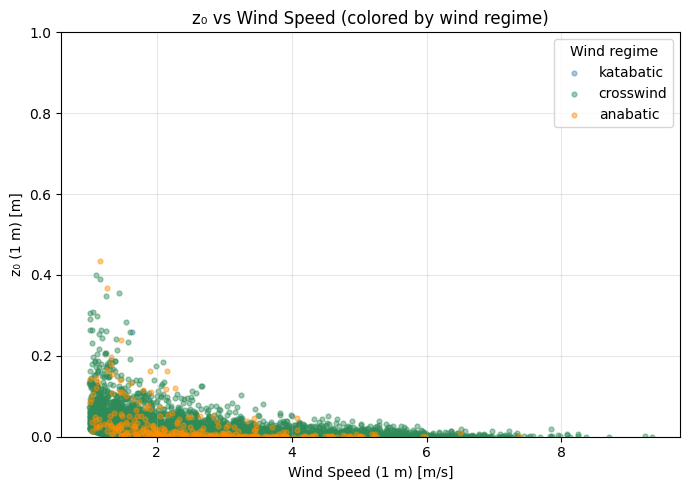

In [12]:
# Scatter plots for z₀ (1 m) with wind-direction color coding
# Define regimes and colors
regimes = {
    "katabatic": {"range": katabatic, "color": "steelblue"},
    "crosswind": {"range": crosswind, "color": "seagreen"},
    "anabatic": {"range": anabatic, "color": "darkorange"},
}

# Precompute numeric columns once
z0_1m = pd.to_numeric(df_clean["z0_1m"], errors="coerce")
wd_1m = pd.to_numeric(df_clean["wind_dir_1m"], errors="coerce") % 360
ws_1m = pd.to_numeric(df_clean["wind_speed_1m"], errors="coerce")

# 1. Scatter: z₀ (1 m) vs wind speed (colored by regime)
fig1, ax1 = plt.subplots(figsize=(7, 5))
for name, cfg in regimes.items():
    mask = direction_mask(wd_1m, cfg["range"])
    ax1.scatter(ws_1m[mask], z0_1m[mask], s=12, alpha=0.45, label=f"{name}", color=cfg["color"])
ax1.set_xlabel("Wind Speed (1 m) [m/s]")
ax1.set_ylabel("z₀ (1 m) [m]")
ax1.set_title("z₀ vs Wind Speed (colored by wind regime)")
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)
ax1.legend(title="Wind regime")
plt.tight_layout()
plt.show()



C:\Users\asemannp\AppData\Local\Temp\ipykernel_12032\2077989918.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bin")["z0"]
C:\Users\asemannp\AppData\Local\Temp\ipykernel_12032\2077989918.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("bin")["z0"]
C:\Users\asemannp\AppData\Local\Temp\ipykernel_12032\2077989918.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group

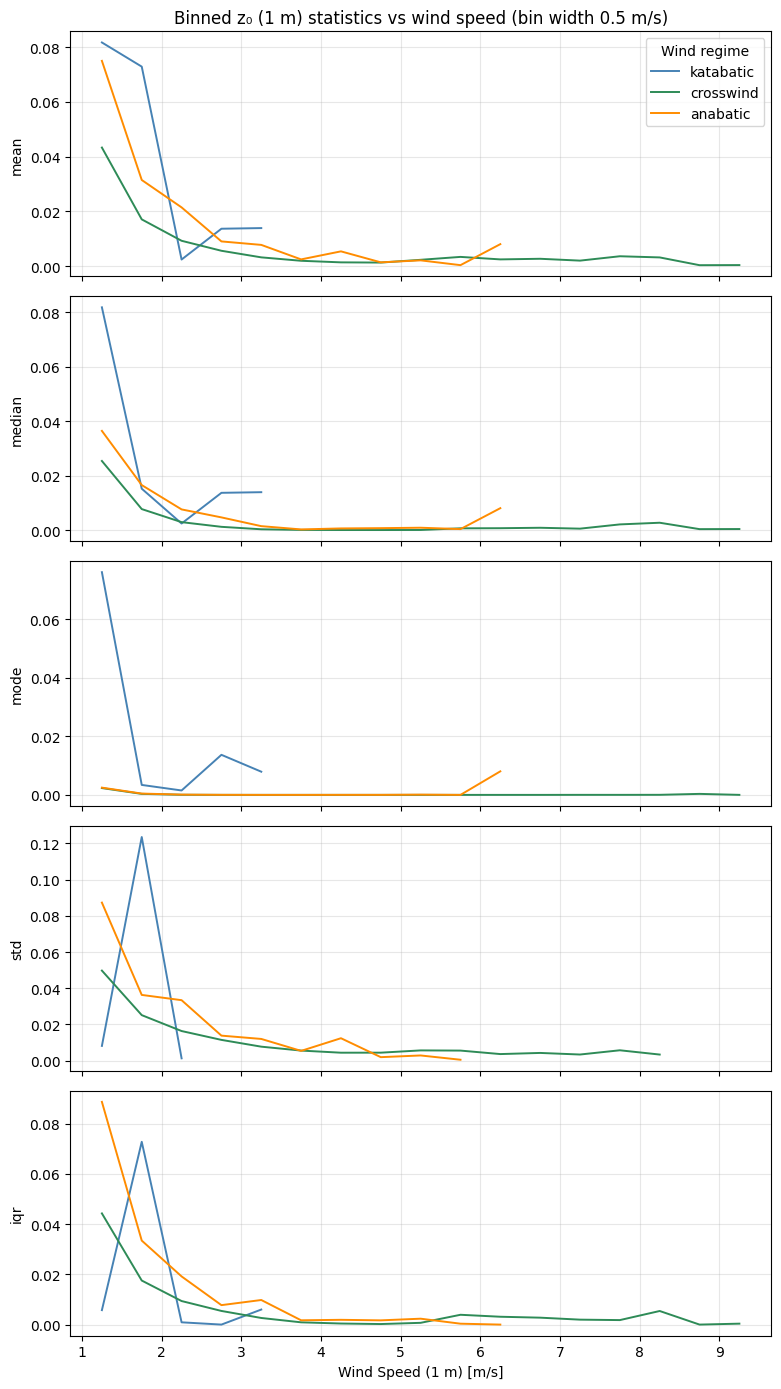

In [13]:
# Binned z₀ (1 m) statistics vs wind speed for each wind-direction regime
bin_width = 0.5  # m/s
ws_max = np.nanmax(ws_1m)
if np.isnan(ws_max) or ws_max <= 0:
    raise ValueError("No wind speed data available for binning.")

bins = np.arange(0, ws_max + bin_width, bin_width)
if bins[-1] < ws_max + bin_width * 0.5:
    bins = np.append(bins, bins[-1] + bin_width)

# Helper to compute binned stats for one regime
stat_cols = ["mean", "median", "mode", "std", "iqr"]


def binned_stats(ws_series, z0_series, mask):
    df = pd.DataFrame({"ws": ws_series[mask], "z0": z0_series[mask]})
    df = df.dropna()
    if df.empty:
        return pd.DataFrame(columns=["bin", "ws_center", *stat_cols])

    df["bin"] = pd.cut(df["ws"], bins=bins, include_lowest=True, right=False)
    grouped = df.groupby("bin")["z0"]

    stats = grouped.agg(
        mean="mean",
        median="median",
        std="std",
        q25=lambda s: s.quantile(0.25),
        q75=lambda s: s.quantile(0.75),
    )
    stats["mode"] = grouped.apply(lambda s: s.mode(dropna=True).iloc[0] if not s.mode(dropna=True).empty else np.nan)
    stats["iqr"] = stats["q75"] - stats["q25"]
    stats = stats.drop(columns=["q25", "q75"])
    stats = stats.reset_index()
    stats["ws_center"] = stats["bin"].apply(lambda iv: iv.left + bin_width / 2)
    return stats

# Compute stats per regime
binned = {}
for name, cfg in regimes.items():
    mask = direction_mask(wd_1m, cfg["range"])
    binned[name] = binned_stats(ws_1m, z0_1m, mask)

# Plot statistics vs wind speed
fig, axes = plt.subplots(len(stat_cols), 1, figsize=(8, 14), sharex=True)
for ax, stat in zip(axes, stat_cols):
    for name, cfg in regimes.items():
        df_stats = binned[name]
        if df_stats.empty:
            continue
        ax.plot(df_stats["ws_center"], df_stats[stat], label=name, color=cfg["color"], linewidth=1.4)
    ax.set_ylabel(stat)
    ax.grid(True, alpha=0.3)
axes[0].legend(title="Wind regime")
axes[-1].set_xlabel("Wind Speed (1 m) [m/s]")
axes[0].set_title("Binned z₀ (1 m) statistics vs wind speed (bin width 0.5 m/s)")
plt.tight_layout()
plt.show()

## 2. Flux Footprint Climatology (FFC)
Skipped in this HEFEX III adaptation for now (missing project-specific footprint inputs).

In [14]:
print("Skipping footprint climatology in this HEFEX III version.")

Skipping footprint climatology in this HEFEX III version.


In [15]:
print("Skipping footprint area calculation in this HEFEX III version.")

Skipping footprint area calculation in this HEFEX III version.


In [16]:
print("Skipping footprint area time-series plot in this HEFEX III version.")

Skipping footprint area time-series plot in this HEFEX III version.


In [17]:
print("Skipping footprint-vs-z0 scatter (3 m) in this HEFEX III version.")

Skipping footprint-vs-z0 scatter (3 m) in this HEFEX III version.


In [18]:
print("Skipping footprint-vs-z0 scatter (1 m) in this HEFEX III version.")

Skipping footprint-vs-z0 scatter (1 m) in this HEFEX III version.
